In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import seaborn as sns
from scipy import signal, stats
from bids import BIDSLayout
import pickle
import glob
import re
from util.io.ffr import *
palette_tab10 = sns.color_palette("tab10", 10)

In [54]:
# accuracy = pd.read_csv('accuracy.csv', index_col = 0)
# med = np.median(accuracy.accuracy)
# low_subs = list(accuracy.subject[accuracy.accuracy < med])
# high_subs = list(accuracy.subject[accuracy.accuracy > med])

In [16]:
pattern = "../data/bids/derivatives/erp/sub-*/*desc-forERPall_epo.fif.gz"
files = glob.glob(pattern)

epochs = []
evokeds = []
target_evs = []
nontarget_evs = []
low_evs = []
high_evs = []

for f in files:
    try:
        epo = mne.read_epochs(f)
    except:
        break

#     # Crop and save all epochs to a list
#     epo = epo.crop(-.1, None).apply_baseline() # baseline from -100ms for prettiness
#     # epochs.append(epo)
#     evo = epo.average()
#     evokeds.append(evo) # save average of all trials

#     # Save epos by condition
#     target_ids = ['11', '22', '33']
#     target = epo[target_ids].average()
#     target_evs.append(target) # average of target trials
#     nontarget_ids = [evid for evid in epo.event_id if not evid in  target_ids]
#     nontarget = epo[nontarget_ids].average() # average of nontarget trials
#     nontarget_evs.append(nontarget)

#     # Save epos by performance
#     sub = re.search(r"sub-(\d+)", f).group(1)
#     if int(sub) in low_subs:
#         low_evs.append(epo.average())
#     else:
#         high_evs.append(epo.average())

# with open('erps.pkl', 'wb') as f:
#     pickle.dump([evokeds, target_evs, nontarget_evs, low_evs, high_evs], f)

# with open('erps.pkl', 'rb') as f:  
#     evokeds, target_evs, nontarget_evs, low_evs, high_evs = pickle.load(f)

Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/erp/sub-7/sub-7_task-pitch_run-1_desc-forERPall_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     499.00 ms
        0 CTF compensation matrices available
Not setting metadata
3077 matching events found
No baseline correction applied
0 projection items activated
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/erp/sub-23/sub-23_task-pitch_run-1_desc-forERPall_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     499.00 ms
        0 CTF compensation matrices available
Not setting metadata
3973 matching events found
No baseline correction applied
0 projection items activated
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/erp/sub-28/sub-28_task-pitch_run-1_desc-forERPall_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     499.00 ms
        0 CTF compe

In [5]:
pattern = "../data/bids/derivatives/erp/sub-*/*desc-forERPall_epo.fif.gz"
files = glob.glob(pattern)

In [10]:
subs = []
for file in files:
    subs.append(int(re.search(r"sub-(\d+)", file).group(1)))

In [13]:
subs.sort()
subs

[3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 44,
 45]

In [14]:
len(subs)

41

Identifying common channels ...
No projector specified for this dataset. Please consider the method self.add_proj.


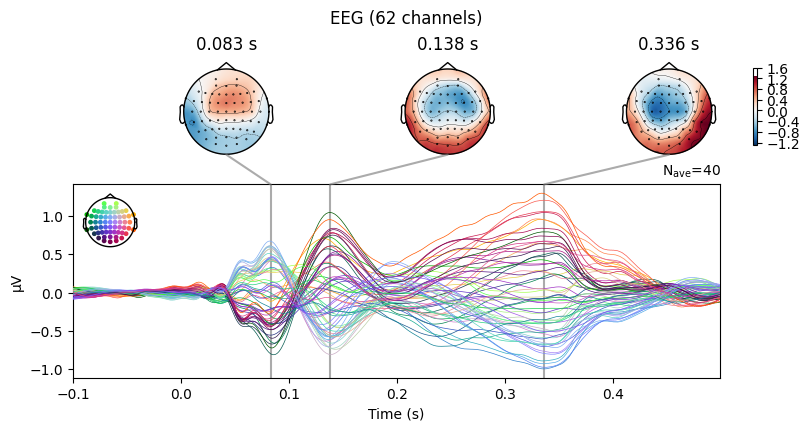

In [4]:
# plot grand average
from eeg_positions import get_elec_coords
evo = mne.grand_average(evokeds)
coords = get_elec_coords(as_mne_montage = True)
evo = evo.set_montage(coords)
fig = evo.plot_joint()
fig.savefig('../figs/erp-grand-average.png', dpi = 300)
plt.show()

## Target vs nontarget

In [5]:
# format data for paired sample target vs. non-target test
target_evs[0].get_data().shape
X = np.stack([t.get_data() for t in target_evs]) - np.stack([nt.get_data() for nt in nontarget_evs])
X.shape

(40, 62, 600)

In [6]:
# one-sample permutation t-test with t-max corrected p-values
_X = X.reshape((X.shape[0], X.shape[1] * X.shape[2]))
t, p, h0 = mne.stats.permutation_t_test(_X, n_jobs = -1)
t = t.reshape(X[0].shape)
p = p.reshape(X[0].shape)
print('p-value for whole ERP is', p.min())

Permuting 9999 times...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 out of  64 | elapsed:    9.9s remaining:   35.2s
[Parallel(n_jobs=-1)]: Done  27 out of  64 | elapsed:   11.0s remaining:   15.0s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:   11.3s remaining:    6.8s
[Parallel(n_jobs=-1)]: Done  53 out of  64 | elapsed:   11.8s remaining:    2.4s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:   12.0s finished


p-value for whole ERP is 0.0001


In [25]:
print(f'maximum t-value: {t.max()}')
print(f'corresponding p-value: {p.min()}')

maximum t-value: 9.126149003606203
corresponding p-value: 0.0001


No projector specified for this dataset. Please consider the method self.add_proj.


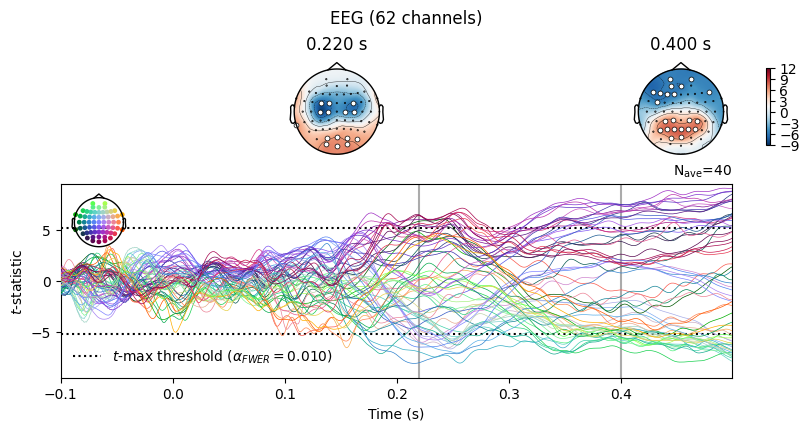

In [70]:
# plot results

alpha = .01

diff = evo.copy() # make a copy of evoked object and replace data
diff.data = t * 1e-6 # because MNE assumes microvolts in plots
fig = diff.plot_joint(
    times = [.22, .4], # you can put these wherever you like 
    topomap_args = dict(
        mask = p < alpha,
        mask_params = dict(markersize = 7),
        vlim = (-9, 12)
    ),
    show = False
)
axs = fig.get_axes()
axs[2].set_ylabel(r'$t$-statistic')
axs[2].set_ylim(-9.5, 9.5)
axs[2].axhline(
    np.quantile(h0, 1 - alpha), 
    color = 'black', linestyle = 'dotted', 
    label = r'$t$-max threshold ($\alpha_{FWER} = %.03f$)'%alpha
)
axs[2].axhline(-np.quantile(h0, 1 - alpha), color = 'black', linestyle = 'dotted')
axs[2].legend(loc = 'lower left', frameon = False)
fig.savefig('../figs/erp-target.png', dpi = 300)
plt.show()

## High vs low accuracy

In [26]:
from mne.parallel import parallel_func
from mne.stats.parametric import ttest_ind_no_p

def _get_t_max(X0, X1, seed):
    '''
    helper function for permutation test
    '''
    rng = np.random.default_rng(seed)
    x = np.concatenate([X0.copy(), X1.copy()])
    if seed != 0: # first permutation is always observed
        rng.shuffle(x, axis = 0) # permute
    x0, x1 = x[:X0.shape[0]], x[X0.shape[0]:]
    t = ttest_ind_no_p(x0, x1, equal_var = False)
    return np.abs(t).max()
    

def permutation_t_test_indep(X0, X1, n_perms = 9999):
    '''
    MNE doesn't provide a function for independent samples t-max procedure, 
    so here is one that does a two-tailed test for H0: X0 - X1 = 0

    Parameters
    ------------
    X0 : np.array of shape (n_subs0, a, b)
        first group
    X1 : np.array of shape (n_subs1, a, b)
        second group
    n_perms : int

    Returns
    ----------
    t : np.array of shape (a, b)
        t-value should be positive where X0 > X1
    p : np.array of shape (a, b)
    H0 : np.array of shape (n_perms,)
    '''
    parallel, p_func, n_jobs = parallel_func(
            _get_t_max, n_jobs = -1,
            verbose = 1
        )
    N_PERMUTATIONS = 100
    out = parallel(
            p_func(X0, X1, seed = i)
            for i in range(n_perms + 1)
        )
    h0 = np.array(out) # null distribution 
    t = ttest_ind_no_p(X0, X1, equal_var = False) # observed
    p = np.vectorize(lambda _t: (h0 >= _t).mean())(np.abs(t))
    print('p-value for whole ERP is', p.min())
    return t, p, h0

In [27]:
X0 = np.stack([l.get_data() for l in low_evs])
X1 = np.stack([h.get_data() for h in high_evs])
t, p, h0 = permutation_t_test_indep(X0, X1)

Got 64 parallel jobs after requesting -1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:   20.5s
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done 1088 tasks      | elapsed:   26.4s
[Parallel(n_jobs=-1)]: Done 1394 tasks      | elapsed:   30.0s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   33.9s
[Parallel(n_jobs=-1)]: Done 2114 tasks      | elapsed:   38.2s
[Parallel(n_jobs=-1)]: Done 2528 tasks      | elapsed:   43.0s
[Parallel(n_jobs=-1)]: Done 2978 tasks      | elapsed:   48.2s
[Parallel(n_jobs=-1)]: Done 3464 tasks      | elapsed:   53.7s
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:   59.5s
[Parallel(n_jobs=-1)]: Done 4544 tasks      | e

p-value for whole ERP is 0.1937


In [28]:
t = t.reshape(X[0].shape)
p = p.reshape(X[0].shape)
# print('p-value for whole ERP is', p.min())
print(f'maximum t-value: {t.max()}')
print(f'corresponding p-value: {p.min()}')

maximum t-value: 4.178413114831454
corresponding p-value: 0.1937


No projector specified for this dataset. Please consider the method self.add_proj.


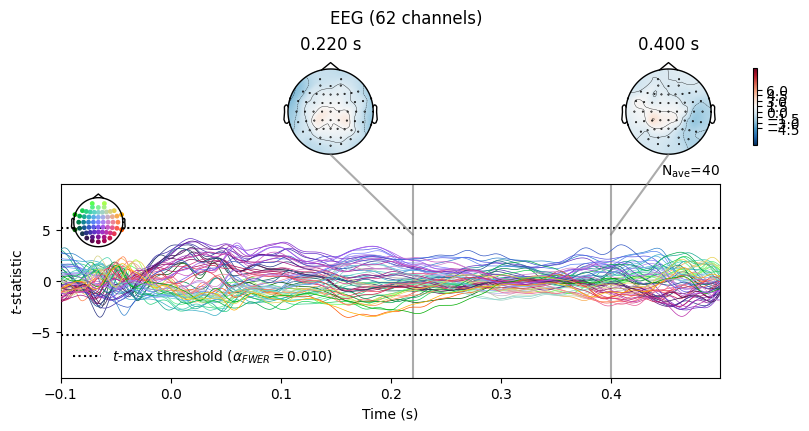

In [65]:
# plot results

alpha = .01

diff = evo.copy() # make a copy of evoked object and replace data
diff.data = t * 1e-6 # because MNE assumes microvolts in plots
fig = diff.plot_joint(
    times = [.22, .4], # you can put these wherever you like 
    topomap_args = dict(
        mask = p < alpha,
        mask_params = dict(markersize = 7),
        vlim = (-9, 12)
    ),
    show = False
)
axs = fig.get_axes()
axs[2].set_ylabel(r'$t$-statistic')
axs[2].set_ylim(-9.5, 9.5)
axs[2].axhline(
    np.quantile(h0, 1 - alpha), 
    color = 'black', linestyle = 'dotted', 
    label = r'$t$-max threshold ($\alpha_{FWER} = %.03f$)'%alpha
)
axs[2].axhline(-np.quantile(h0, 1 - alpha), color = 'black', linestyle = 'dotted')
axs[2].legend(loc = 'lower left', frameon = False)
fig.savefig('../figs/erp-accuracy.png', dpi = 300)
plt.show()